# ReMi (Refraction Microtremor) Processing for Cook Strait DAS

**Author:** Shihao Yuan (ISTerre, UGE, France)  
**Contact:** shihao.yuan@univ-grenoble-alpes.fr

This notebook applies the **ReMi-DAS** workflow to the Cook Strait DAS data,
using the **traffic / anthropogenic noise** recorded along the near-shore
segment of the cable (2.4 – 3.0 km) shown in
[`2-DAS_Examples.ipynb`](2-DAS_Examples.ipynb).

The workflow follows
[Shihao-Yuan/ReMi-DAS](https://github.com/Shihao-Yuan/ReMi-DAS) and consists
of:

1. Reading and preprocessing the continuous DAS data (select the traffic-noise
   sub-array, detrend, decimate, taper, band-pass filter).
2. Slowness-frequency (p–f) transformation: chunk into overlapping windows,
   apply a tau-p (slant-stack) transform, then a DFT along time.
3. Power-spectrum normalisation and stacking across all chunks.
4. Interactive Rayleigh-wave phase-velocity dispersion picking and
   cubic-spline interpolation.

### References

- McMechan, G.A. and Yedlin, M.J., 1981. Analysis of dispersive waves by wave
  field transformation. *Geophysics*, 46(6), pp.869–874.
- Louie, J.N., 2001. Faster, better: shear-wave velocity to 100 meters depth
  from refraction microtremor arrays. *BSSA*, 91(2), pp.347–364.
- Chambers, D., Jin, G., Tourei, A., et al., 2024. DASCore: A Python library
  for distributed fiber optic sensing. *Seismica*, 3(2), pp.10–26443.

## 1. Setup

If you have not yet installed `dascore`, uncomment the install cell below.
A Qt backend is used so that interactive picking (`fig.ginput`) works in
JupyterLab; switch to `%matplotlib inline` if you only want static plots.

In [ ]:
# !pip install dascore --upgrade --quiet
# !pip install PyQt5 --upgrade --quiet

In [ ]:
import os

import numpy as np
from scipy.interpolate import CubicSpline

import dascore as dc
from dascore.units import Hz

from matplotlib import pyplot as plt

# Use Qt backend for interactive picking
# `%matplotlib inline` for static plots only.
%matplotlib qt

print(f"DASCore version: {dc.__version__}")

DASCore version: 0.1.16


## 2. Load the merged, preprocessed patch

We use the single HDF5 file produced by
[`data-prep/1-Prepare_Continuous_Data.ipynb`](data-prep/1-Prepare_Continuous_Data.ipynb),
which already contains the selected sub-array and time window with the
DASCore preprocessing chain applied (set units, detrend, decimate, taper,
band-pass filter). Loading is therefore a single line.

Update `prepared_file` if your data-prep notebook wrote to a different
location.

In [ ]:

prepared_file = "./data-prep/prepared_data/continuous_remi_input_284.h5"

if not os.path.isabs(prepared_file) and not os.path.exists(prepared_file):
    alt = os.path.join("notebooks", "prepared_data",
                       os.path.basename(prepared_file))
    if os.path.exists(alt):
        prepared_file = alt

if not os.path.exists(prepared_file):
    raise FileNotFoundError(
        f"Could not find {prepared_file!r}. Run "
        "`data-prep/1-Prepare_Continuous_Data.ipynb` first, or update "
        "`prepared_file` to point at your merged HDF5."
    )

print(f"Loading: {os.path.abspath(prepared_file)}")
spool_pa = dc.spool(prepared_file)
patch_in = spool_pa[0]

Loading: /Users/shihao/Research/GNS/repositoy/CookStrait-DAS-Processing/notebooks/data-prep/prepared_data/continuous_remi_input_284.h5


In [ ]:
dist_coord = patch_in.get_coord("distance")
time_coord = patch_in.get_coord("time")
n_t = patch_in.data.shape[patch_in.dims.index("time")]
n_d = patch_in.data.shape[patch_in.dims.index("distance")]
dt_s = (time_coord[1] - time_coord[0]) / np.timedelta64(1, "s")

print(f"Patch dims        : {patch_in.dims}")
print(f"Distance range    : {dist_coord.min():.1f} - {dist_coord.max():.1f} m  ({n_d} channels)")
print(f"Time range        : {time_coord.min()}  ->  {time_coord.max()}")
print(f"Duration          : {n_t * dt_s:.1f} s  ({n_t * dt_s / 60:.2f} min)")
print(f"Sampling interval : {dt_s*1000:.3f} ms  ({1/dt_s:.1f} Hz)")

Patch dims        : ('time', 'distance')
Distance range    : 2412.0 - 2999.0 m  (47 channels)
Time range        : 2025-10-11T03:00:00.000028891  ->  2025-10-11T03:59:59.998228891
Duration          : 3600.0 s  (60.00 min)
Sampling interval : 4.000 ms  (250.0 Hz)


In [ ]:
# Visualize data sample
fig, ax = plt.subplots(figsize=(10, 6))
pa_fil.viz.waterfall(ax=ax, scale=0.001)
ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Distance (m)", fontsize=14)
ax.set_title("Traffic / anthropogenic noise (2.4 - 3.0 km)", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Slowness-frequency (p-f) analysis

This block follows the ReMi-DAS workflow and:

- chunks the patch into overlapping time windows,
- applies tapers in both time and distance to suppress edge effects,
- performs a tau-p (slant-stack) transform across a velocity grid,
- takes a DFT along time to obtain the slowness-frequency spectrum.

The resulting spool of patches will be stacked and normalised in the next
section.

In [ ]:
# Helper functions for each processing step
def taper(patch, time, window_type):
    """Apply a taper along the time axis."""
    return patch.taper(time=0.1, window_type=window_type)

def taper_d(patch, distance, window_type):
    """Apply a taper along the distance axis."""
    return patch.taper(distance=0.1, window_type=window_type)

def taup(patch, velocities):
    """Apply tau-p (slant-stack) transform with given velocities."""
    return patch.tau_p(velocities)

def dft(patch, dim="time"):
    """Apply discrete Fourier transform along the specified dimension."""
    return patch.dft(dim="time", real=True)


# Wrap the preprocessed patch into a spool
sp_fil = dc.spool(pa_fil)

# Chunk into 40 s segments with 10 s overlap
sp_fil_chunked = sp_fil.chunk(time=40, overlap=10)

# Taper in time
sp_fil_chunked_taper = dc.spool(
    sp_fil_chunked.map(taper, time=0.1, window_type="hann")
)

# Taper in distance
sp_fil_chunked_taper_d = dc.spool(
    sp_fil_chunked_taper.map(taper_d, distance=0.1, window_type="hann")
)

# Tau-p transform across a velocity grid (m/s)
velocities = np.arange(100, 1000, 10)
sp_fil_chunked_taper_taup = dc.spool(
    sp_fil_chunked_taper_d.map(taup, velocities=velocities)
)

# DFT along time -> slowness-frequency patches
sp_fil_chunked_taper_taup_dft = dc.spool(
    sp_fil_chunked_taper_taup.map(dft, dim="time")
)

print(f"Number of (overlapping) chunks: {len(sp_fil_chunked_taper_taup_dft)}")

## 4. Spectral normalisation and stacking

For each chunk we compute the power spectrum (\(|F|^2\)), fold the negative
slowness side onto the positive side to enforce symmetry, normalise each
frequency bin by its mean across slowness, and stack across all chunks. The
result, `summed_avg_stack`, is a 2-D array of normalised power as a function
of frequency and slowness ready for dispersion picking.

In [ ]:
n_freq = sp_fil_chunked_taper_taup_dft[0].data.shape[0]
half   = n_freq // 2

if n_freq % 2 == 0:
    summed_avg_stack = np.zeros(
        (half, sp_fil_chunked_taper_taup_dft[0].data.shape[1])
    )
else:
    summed_avg_stack = np.zeros(
        (half + 1, sp_fil_chunked_taper_taup_dft[0].data.shape[1])
    )

for i, patch in enumerate(sp_fil_chunked_taper_taup_dft):

    power_spectrum = (patch.data * np.conj(patch.data)).real

    if n_freq % 2 == 0:
        neg = power_spectrum[:half, :]
        pos = power_spectrum[half:, :]
        neg_flipped = np.flipud(neg)
        summed = pos + neg_flipped
    else:
        pos = power_spectrum[:half + 1]
        neg = power_spectrum[half + 1:]
        neg_flipped = np.flipud(neg)
        summed = pos + neg_flipped[:pos.shape[0]]

    avg = np.sum(summed, axis=0) / len(summed)
    summed_avg = summed / avg

    summed_avg_stack += summed_avg

print("Stacked spectrum shape:", summed_avg_stack.shape)

Stacked spectrum shape: (90, 2501)


## 5. Rayleigh phase-velocity dispersion picking

The normalized, stacked power spectrum is shown as a frequency vs apparent
velocity image. Click points along the visible dispersion ridge and press
**Enter** to finish. Picks are sorted in frequency, smoothed with a cubic
spline, and overlaid on the spectrum.

> **Tip:** if `fig.ginput` does not block (no interactive window), make sure
> `%matplotlib qt` was selected in the setup cell and that PyQt5 is
> installed.

In [ ]:
freq     = sp_fil_chunked_taper_taup_dft[0].get_coord("ft_time")[:summed.shape[1]]
slowness = sp_fil_chunked_taper_taup_dft[0].get_coord("slowness")[half:]

# Display ranges (Hz, m/s) for picking and final plotting
F_MIN, F_MAX = 1, 10
V_MIN, V_MAX = 100, 800

fig, ax = plt.subplots(figsize=(10, 5))
extent = [freq[0], freq[-1], 1 / slowness[0], 1 / slowness[-1]]
im = ax.imshow(
    summed_avg_stack ** 2,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="plasma",
    vmin=0,
    vmax=np.max(summed_avg_stack ** 2 * 0.5), 
)
ax.set_xlabel("Frequency (Hz)", fontsize=14)
ax.set_ylabel("Apparent Velocity (m/s)", fontsize=14)
ax.set_title("Click to pick points, then press Enter", fontsize=14)
ax.set_xlim(F_MIN, F_MAX)
ax.set_ylim(V_MIN, V_MAX)
fig.colorbar(im, ax=ax, label="Amplitude")

print("Click to pick points along the dispersion curve. Press Enter when done.")
picked = fig.ginput(n=-1, timeout=0)  
plt.close(fig)

picked = np.array(picked)
if picked.shape[0] < 2:
    print("Not enough points picked for interpolation.")
    freq_interp = np.array([])
    velocity_interp = np.array([])
else:
    picked = picked[np.argsort(picked[:, 0])]
    cs = CubicSpline(picked[:, 0], picked[:, 1])
    freq_interp = np.linspace(picked[:, 0].min(), picked[:, 0].max(), 200)
    velocity_interp = cs(freq_interp)

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    im2 = ax2.imshow(
        summed_avg_stack ** 2,
        aspect="auto",
        origin="lower",
        extent=extent,
        cmap="plasma",
        vmin=0,
        vmax=np.max(summed_avg_stack ** 2 * 0.3) ,
    )
    ax2.set_xlabel("Frequency (Hz)", fontsize=14)
    ax2.set_ylabel("Apparent Velocity (m/s)", fontsize=14)
    ax2.set_title("Manual picks + cubic-spline interpolation", fontsize=14)
    ax2.set_xlim(F_MIN, F_MAX)
    ax2.set_ylim(V_MIN, V_MAX)
    fig2.colorbar(im2, ax=ax2, label="Amplitude")
    ax2.plot(picked[:, 0], picked[:, 1], "ro", label="Picked points")
    ax2.plot(freq_interp, velocity_interp, "b-", linewidth=2,
             label="Cubic spline")
    ax2.legend()
    plt.show()

Click to pick points along the dispersion curve. Press Enter when done.
Not enough points picked for interpolation.


## 6. Static summary plot

A static (non-interactive) version of the stacked spectrum with the picked
dispersion curve overlaid, suitable for inclusion in reports or notebooks
viewed without a Qt backend.

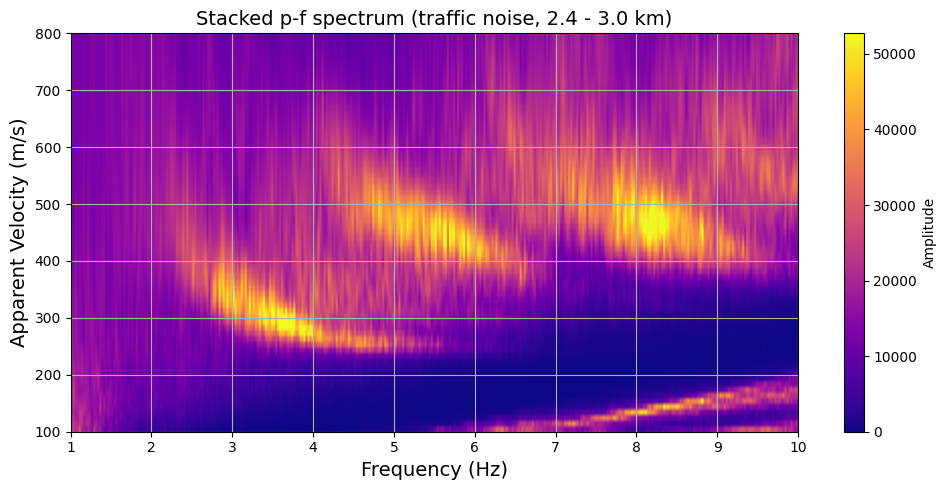

In [45]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(10, 5))
extent = [freq[0], freq[-1], 1 / slowness[0], 1 / slowness[-1]]
im = ax.imshow(
    summed_avg_stack ** 2,
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="plasma",
    vmin=0,
    vmax=np.max(summed_avg_stack ** 2) * 0.3
)
if picked.size:
    ax.plot(picked[:, 0], picked[:, 1], "ro", label="Picked points")
    ax.plot(freq_interp, velocity_interp, "b-", linewidth=2,
            label="Cubic spline")
    ax.legend()
ax.set_xlabel("Frequency (Hz)", fontsize=14)
ax.set_ylabel("Apparent Velocity (m/s)", fontsize=14)
ax.set_title("Stacked p-f spectrum (traffic noise, 2.4 - 3.0 km)", fontsize=14)
ax.set_xlim(F_MIN, F_MAX)
ax.set_ylim(V_MIN, V_MAX)
ax.grid('both')
fig.colorbar(im, ax=ax, label="Amplitude")
plt.tight_layout()
plt.show()

## 7. (Optional) Save picked dispersion curve

Save the picked points and the smoothed dispersion curve to disk for
subsequent 1-D shear-wave velocity inversion (e.g. with `disba`,
`evodcinv`, or `BayHunter`).

In [ ]:
out_dir = "./remi_output"
os.makedirs(out_dir, exist_ok=True)

if picked.size:
    np.savetxt(
        os.path.join(out_dir, "dispersion_picks.csv"),
        picked,
        delimiter=",",
        header="frequency_Hz,phase_velocity_m_s",
        comments="",
    )
    np.savetxt(
        os.path.join(out_dir, "dispersion_spline.csv"),
        np.column_stack([freq_interp, velocity_interp]),
        delimiter=",",
        header="frequency_Hz,phase_velocity_m_s",
        comments="",
    )
    print(f"Saved picks and spline to {out_dir}/")
else:
    print("No picks to save.")